In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/tripadvisor_hotel_reviews.csv")

print("Data loaded successfully!")
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
df.head()

Data loaded successfully!
Shape: (20491, 2)

Column names: ['Review', 'Rating']


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [5]:
print(df["Rating"].value_counts().sort_index())
print("\nAverage rating:", round(df["Rating"].mean(), 2))

Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64

Average rating: 3.95


In [6]:
def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["Sentiment"] = df["Rating"].apply(get_sentiment)

print(df["Sentiment"].value_counts())
print("\nFirst 5 rows with Sentiment:")
df[["Review", "Rating", "Sentiment"]].head()

Sentiment
Positive    15093
Negative     3214
Neutral      2184
Name: count, dtype: int64

First 5 rows with Sentiment:


,Review,Rating,Sentiment
0,nice hotel expensive parking got good deal sta...,4,Positive
1,ok nothing special charge diamond member hilto...,2,Negative
2,nice rooms not 4* experience hotel monaco seat...,3,Neutral
3,"unique, great stay, wonderful time hotel monac...",5,Positive
4,"great stay great stay, went seahawk game aweso...",5,Positive


In [10]:
import re
import string

def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["Clean_Review"] = df["Review"].apply(clean_text)

print("Example of cleaned text:")
print("Original :", df["Review"].iloc[0][:150])
print("Cleaned  :", df["Clean_Review"].iloc[0][:150])

Example of cleaned text:
Original : nice hotel expensive parking got good deal stay hotel anniversary, arrived late evening took advice previous reviews did valet parking, check quick ea
Cleaned  : nice hotel expensive parking got good deal stay hotel anniversary arrived late evening took advice previous reviews did valet parking check quick easy


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Features (cleaned review) and target (Sentiment)
X = df["Clean_Review"]
y = df["Sentiment"]

#Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Create TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")

# Fit on training data and transform both sets 
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_traintfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_traintfidf shape: (16392, 5000)
X_test_tfidf shape: (4099, 5000)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Create the model
model = LogisticRegression(max_iter=1000, random_state=42)

#Train the model 
model.fit(X_train_tfidf, y_train)

# Make predictions 
y_pred = model.predict(X_test_tfidf)

#Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8561

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.77      0.78       643
     Neutral       0.47      0.18      0.26       437
    Positive       0.89      0.97      0.93      3019

    accuracy                           0.86      4099
   macro avg       0.72      0.64      0.66      4099
weighted avg       0.83      0.86      0.83      4099



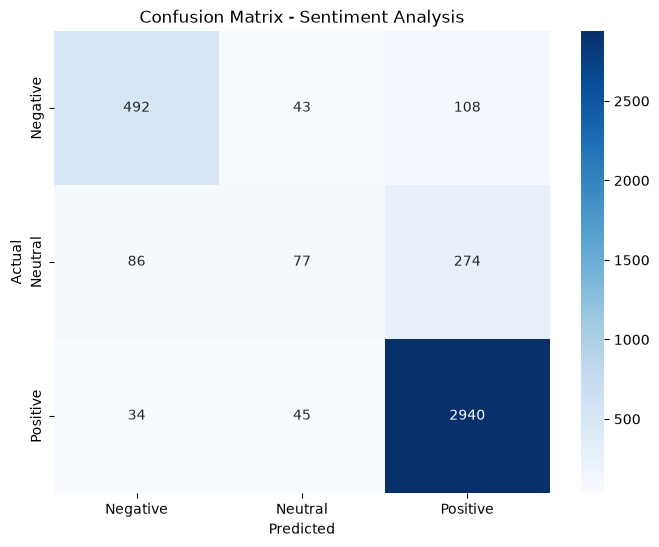

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=["Negative", "Neutral", "Positive"])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Sentiment Analysis")
plt.show()

In [20]:
from collections import Counter

# Take only Negative reviews
negative_reviews = df[df["Sentiment"] == "Negative"]["Clean_Review"]

# Join all negative reviews into one big text
all_negative_text = " ".join(negative_reviews)

# Split into words
words = all_negative_text.split()

# Count word frequencies
word_counts = Counter(words)

# Show the 30 most common words
print("Most common words in Negative reviews:")
print(word_counts.most_common(30))

Most common words in Negative reviews:
[('not', 8993), ('hotel', 7773), ('room', 7530), ('nt', 4033), ('no', 3548), ('did', 3138), ('stay', 2577), ('rooms', 2250), ('staff', 2244), ('good', 2091), ('just', 2062), ('service', 2035), ('night', 2016), ('day', 1869), ('time', 1736), ('like', 1714), ('food', 1684), ('resort', 1600), ('stayed', 1500), ('beach', 1478), ('got', 1472), ('nice', 1416), ('told', 1399), ('people', 1375), ('desk', 1373), ('place', 1310), ('great', 1228), ('really', 1129), ('2', 1123), ('went', 1081)]


In [21]:
from collections import Counter
import re

# List of useful theme-related words
theme_keywords = [
    "dirty", "clean", "cleanliness", "smell", "smelly", "filthy",
    "staff", "rude", "unfriendly", "helpful", "service", "desk", "reception",
    "price", "expensive", "cheap", "overpriced", "value", "money",
    "room", "bathroom", "bed", "noisy", "noise", "loud", "small",
    "wifi", "internet", "breakfast", "food", "pool", "parking",
    "location", "far", "broken", "old", "maintenance", "air", "conditioning", "ac"
]

# Get only Negative reviews
negative_text = " ".join(df[df["Sentiment"] == "Negative"]["Clean_Review"])

# Count how many times each theme word appears
theme_counts = {}
for word in theme_keywords:
    count = len(re.findall(r'\b' + word + r'\b', negative_text))
    if count > 0:
        theme_counts[word] = count

# Sort by most frequent
sorted_themes = sorted(theme_counts.items(), key=lambda x: x[1], reverse=True)

print("Common complaint themes in Negative reviews:")
for word, count in sorted_themes:
    print(f"{word:20} → {count}")

Common complaint themes in Negative reviews:
room                 → 7530
staff                → 2244
service              → 2035
food                 → 1684
desk                 → 1373
bed                  → 1077
breakfast            → 1047
pool                 → 1035
small                → 992
location             → 922
bathroom             → 907
clean                → 903
money                → 683
old                  → 663
price                → 566
dirty                → 516
air                  → 511
reception            → 478
rude                 → 432
far                  → 406
noise                → 391
parking              → 356
internet             → 334
helpful              → 321
expensive            → 292
smell                → 291
noisy                → 271
broken               → 258
cheap                → 241
loud                 → 217
ac                   → 203
conditioning         → 193
overpriced           → 146
value                → 136
filthy               → 115
un

In [22]:
print("="*55)
print("PROJECT 2 SUMMARY - Hotel Review Sentiment Analysis")
print("="*55)
print(f"Total reviews: {len(df)}")
print(f"Sentiment distribution:\n{df['Sentiment'].value_counts()}")
print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nTop complaint themes in Negative reviews:")
for word, count in sorted_themes[:10]:
    print(f"  - {word}: {count}")

PROJECT 2 SUMMARY - Hotel Review Sentiment Analysis
Total reviews: 20491
Sentiment distribution:
Sentiment
Positive    15093
Negative     3214
Neutral      2184
Name: count, dtype: int64

Model Accuracy: 0.8561

Top complaint themes in Negative reviews:
  - room: 7530
  - staff: 2244
  - service: 2035
  - food: 1684
  - desk: 1373
  - bed: 1077
  - breakfast: 1047
  - pool: 1035
  - small: 992
  - location: 922
